<a href="https://colab.research.google.com/github/manyanaidu28/Week2-EDA-Telco-Churn/blob/main/Week2_EDA_Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("DATASET INFORMATION")
print("--------------------")
df.info()

print("\nSTATISTICAL SUMMARY")
print("-------------------")
display(df.describe())

DATASET INFORMATION
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print("CHURN DISTRIBUTION")
print("------------------")

churn_counts = df["Churn"].value_counts()

print(churn_counts)

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

CHURN DISTRIBUTION
------------------
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


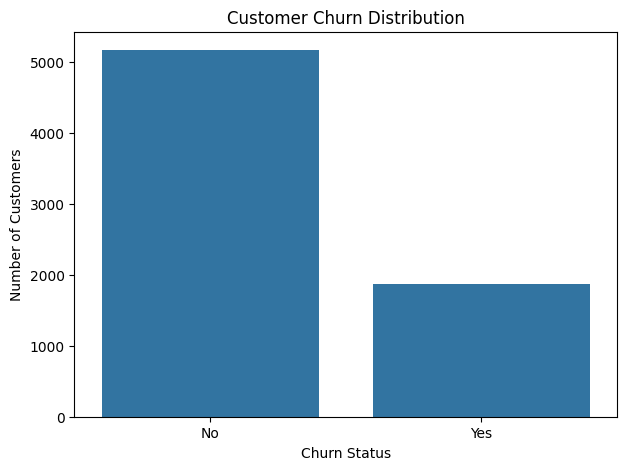

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
print("TENURE SUMMARY")
print("--------------")

print("Average tenure:", round(df["tenure"].mean(), 2), "months")
print("Median tenure:", df["tenure"].median(), "months")
print("Minimum tenure:", df["tenure"].min(), "months")
print("Maximum tenure:", df["tenure"].max(), "months")

TENURE SUMMARY
--------------
Average tenure: 32.37 months
Median tenure: 29.0 months
Minimum tenure: 0 months
Maximum tenure: 72 months


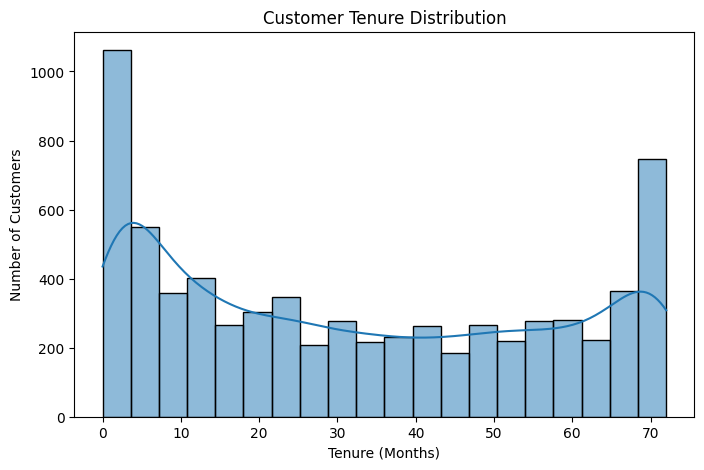

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", bins=20, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
print("MONTHLY CHARGES SUMMARY")
print("-----------------------")

print("Average Monthly Charges:", round(df["MonthlyCharges"].mean(), 2))
print("Median Monthly Charges:", round(df["MonthlyCharges"].median(), 2))
print("Minimum Monthly Charges:", df["MonthlyCharges"].min())
print("Maximum Monthly Charges:", df["MonthlyCharges"].max())

MONTHLY CHARGES SUMMARY
-----------------------
Average Monthly Charges: 64.76
Median Monthly Charges: 70.35
Minimum Monthly Charges: 18.25
Maximum Monthly Charges: 118.75


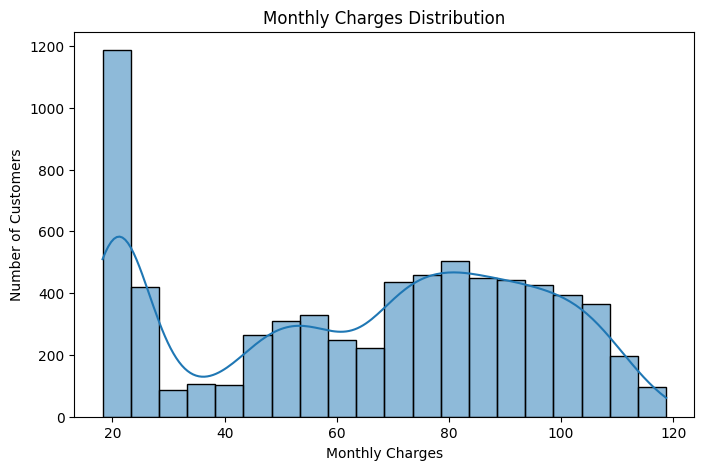

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="MonthlyCharges", bins=20, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

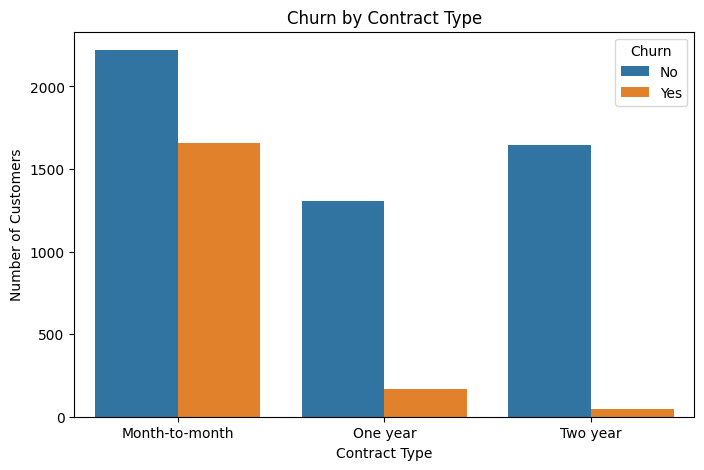

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

In [ ]:
contract_churn_rate = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print("CHURN RATE BY CONTRACT TYPE")
print(contract_churn_rate.round(2))

CHURN RATE BY CONTRACT TYPE
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


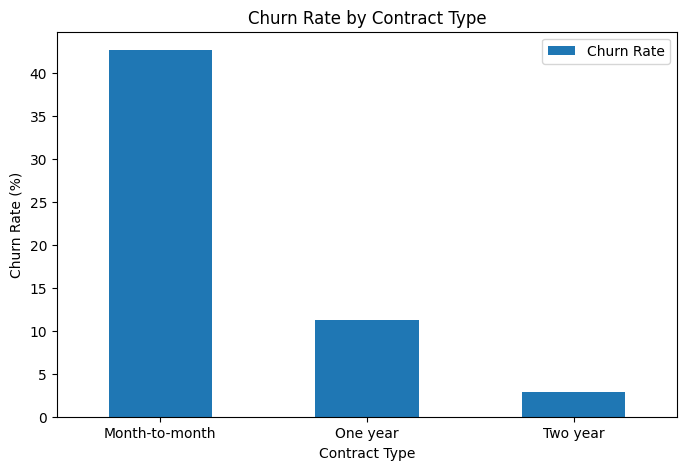

In [ ]:
contract_churn_rate[["Yes"]].plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(["Churn Rate"])

plt.show()

In [ ]:
internet_churn_rate = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

print("CHURN RATE BY INTERNET SERVICE")
print(internet_churn_rate.round(2))

CHURN RATE BY INTERNET SERVICE
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


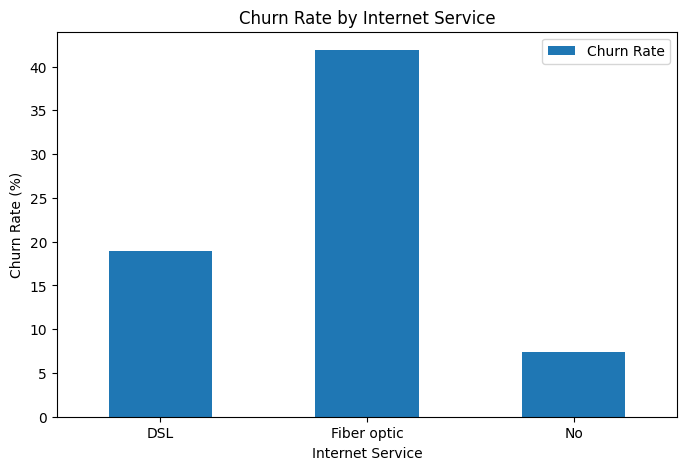

In [ ]:
internet_churn_rate["Yes"].plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(["Churn Rate"])

plt.show()

In [ ]:
payment_churn_rate = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

print("CHURN RATE BY PAYMENT METHOD")
print(payment_churn_rate.round(2))

CHURN RATE BY PAYMENT METHOD
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


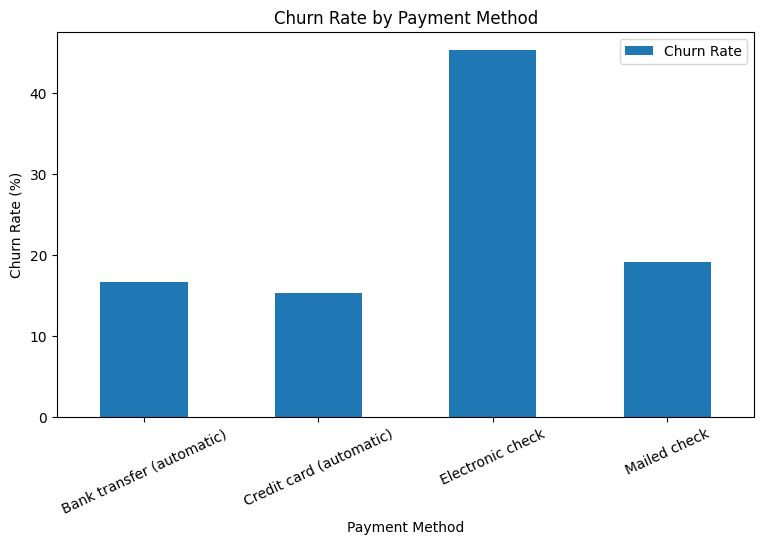

In [ ]:
payment_churn_rate["Yes"].plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25)
plt.legend(["Churn Rate"])

plt.show()

In [ ]:
print("AVERAGE MONTHLY CHARGES BY CHURN")
print("--------------------------------")

charges_by_churn = df.groupby("Churn")["MonthlyCharges"].mean().round(2)

print(charges_by_churn)

AVERAGE MONTHLY CHARGES BY CHURN
--------------------------------
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


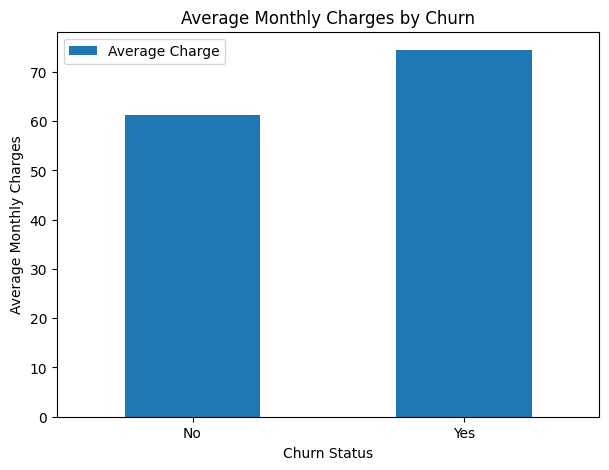

In [ ]:
charges_by_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.legend(["Average Charge"])

plt.show()

In [ ]:

print("FINAL EDA SUMMARY")
print("=" * 40)

print("Total Customers:", len(df))
print("Total Churned Customers:", (df["Churn"] == "Yes").sum())
print("Overall Churn Rate:",
      round((df["Churn"] == "Yes").mean() * 100, 2), "%")

print("\nAverage Tenure:",
      round(df["tenure"].mean(), 2), "months")

print("Average Monthly Charges:",
      round(df["MonthlyCharges"].mean(), 2))

print("\nAverage Monthly Charges by Churn:")
print(charges_by_churn)

print("\nChurn Rate by Contract Type:")
print(contract_churn_rate["Yes"].round(2))

print("\nChurn Rate by Internet Service:")
print(internet_churn_rate["Yes"].round(2))

print("\nChurn Rate by Payment Method:")
print(payment_churn_rate["Yes"].round(2))

FINAL EDA SUMMARY
Total Customers: 7043
Total Churned Customers: 1869
Overall Churn Rate: 26.54 %

Average Tenure: 32.37 months
Average Monthly Charges: 64.76

Average Monthly Charges by Churn:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

Churn Rate by Internet Service:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Yes, dtype: float64

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Yes, dtype: float64
